In [21]:
using LensFactory
using LensFactory.Constants
using CairoMakie

# Initialize a cosmology

In [22]:
# Initialize default cosmology
cosmo = Cosmology.init_cosmology()

# Lens and source redshifts
zl = 0.5
zs = 1.5

# ADDs and distance ratio
Dol = Cosmology.angular_diameter_distance(cosmo, 0., zl)
Dls = Cosmology.angular_diameter_distance(cosmo, zl, zs)
Dos = Cosmology.angular_diameter_distance(cosmo, 0., zs)
adis = Dls/Dos

0.5672117739208741

# Create a grid

In [23]:
# Create image plane grid (default units are ANGLE_ARCSEC)
x, y = Lenses.get_meshgrid(5, 5, 0.03);

# Hernquist Lens

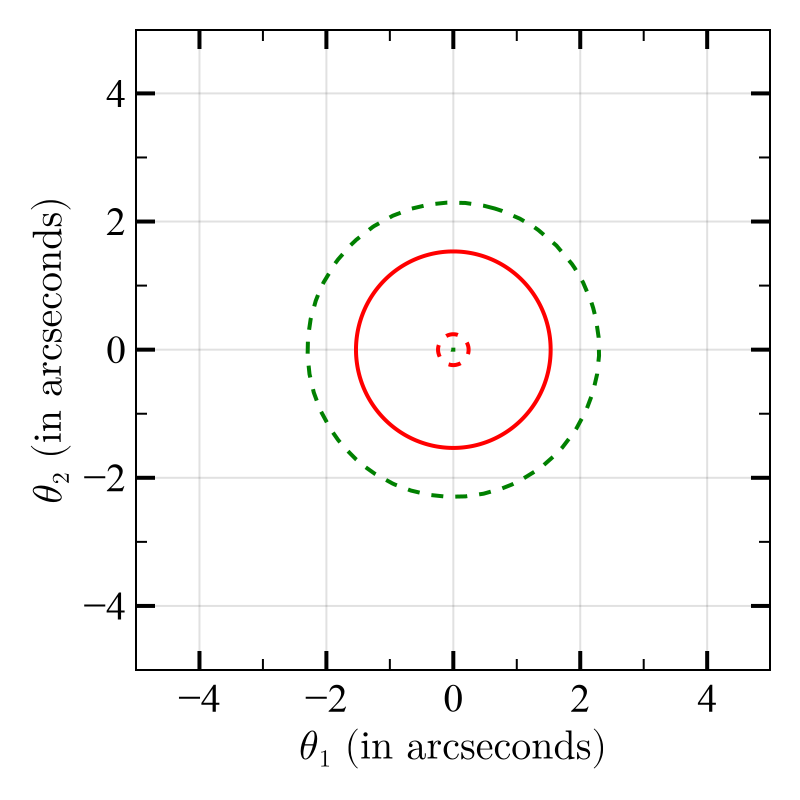

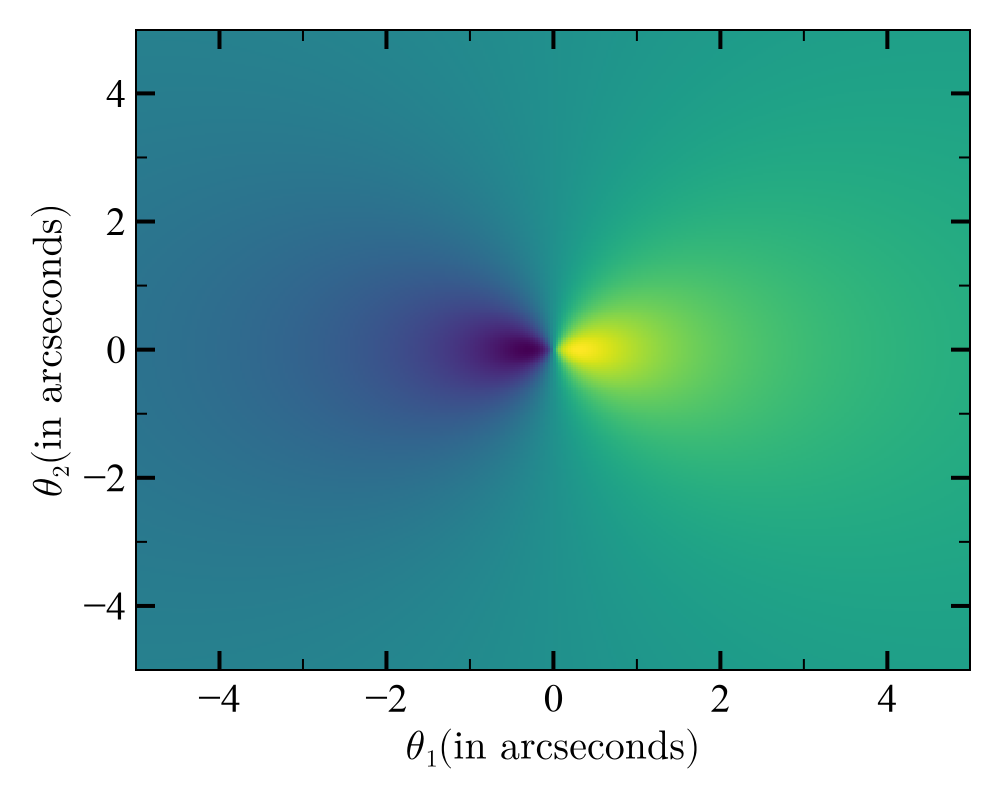

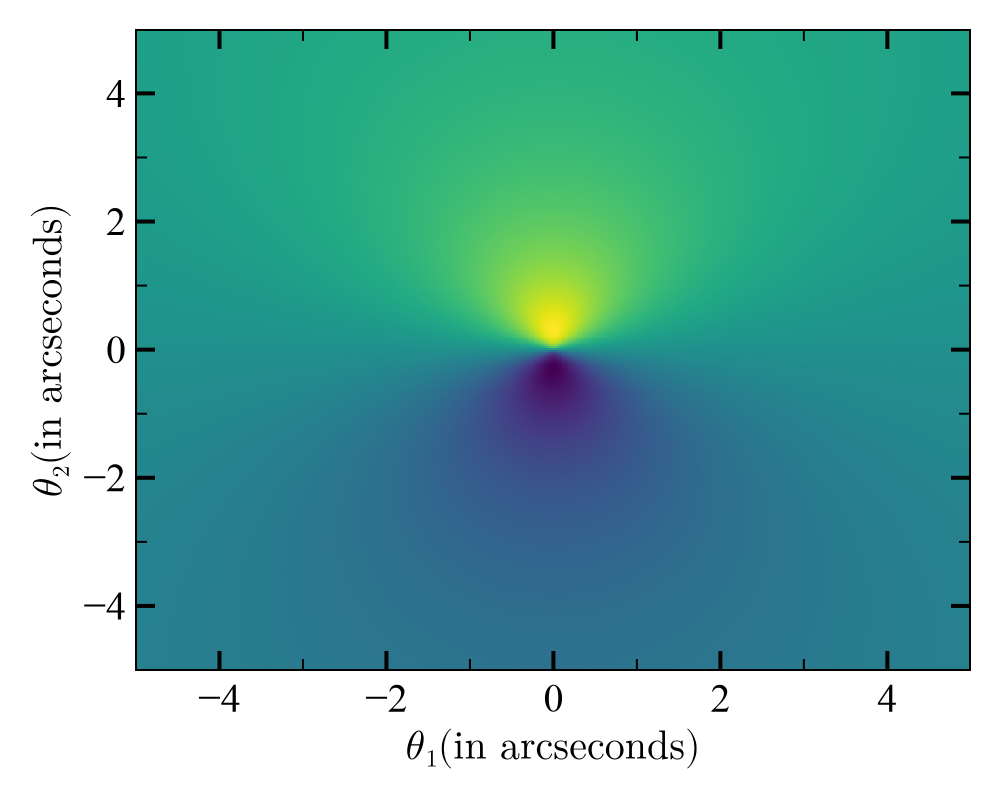

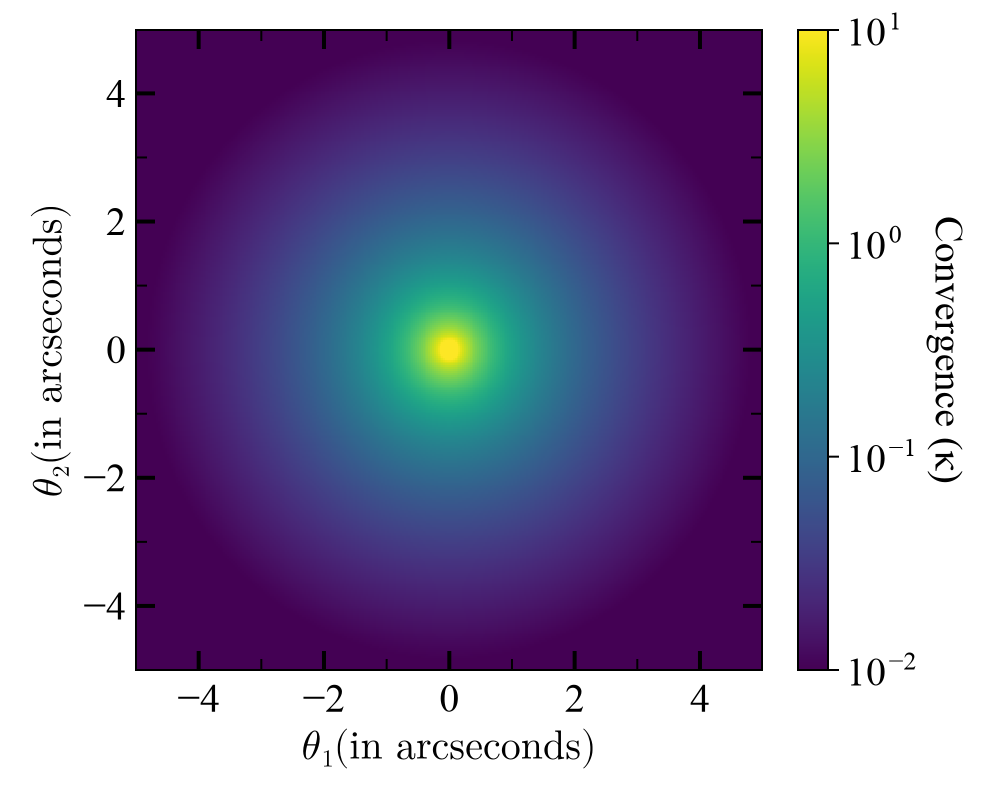

CairoMakie.Screen{IMAGE}


In [49]:
# Initialize a Hernquist lens model
lens = Lenses.init_HernquistLens(D_d=Dol, mass=1.0E12*MASS_SUN, x_s=0.5)

# Plot the image plane
fig, ax = Lenses.plot_image_plane(lens, x, y, adis)
display(fig)

# Get scaled deflection maps
dx, dy = Lenses.get_deflection(lens, x, y)

# Re-scale deflection maps to source plane
@. dx = adis * dx
@. dy = adis * dy

# Plot the deflection map(s)
fig, ax = Lenses.plot_sky(x, y)
heatmap!(ax, x[:,1], y[1,:], dx)
display(fig)

heatmap!(ax, x[:,1], y[1,:], dy)
display(fig)

# Get scaled Jacobian components
dxx, dyy, dxy = Lenses.get_jacobian(lens, x, y)

# Re-scale Jacobian components to source plane
@. dxx = adis * dxx
@. dyy = adis * dyy
@. dxy = adis * dxy

# Get convergence and shear maps from Jacobian components
kappa = 0.5 .* (dxx .+ dyy)
gamma1 = 0.5 .* (dxx .- dyy)
gamma2 = dxy

# Plot one of the Jacobian component map
fig, ax = Lenses.plot_sky(x, y)
cs = heatmap!(ax, x[:,1], y[1,:], kappa, colormap=:viridis, colorrange=(1E-2, 10.0), colorscale=log10)
cb = Colorbar(fig[1,2], cs; label="Convergence (κ)", width=15, labelrotation=3π/2)
display(fig)

# NFW Lens
To fully define NFW lens, we need (`rho_s`, `x_s`, `c`), where  `rho_s` is the characteristic density (in kg/m^3) and `x_s` is the scale radius (in arcseconds). `Lenses` module has a helper function, `parameter_NFWLens` to determine all of these parameters (and additional ones).

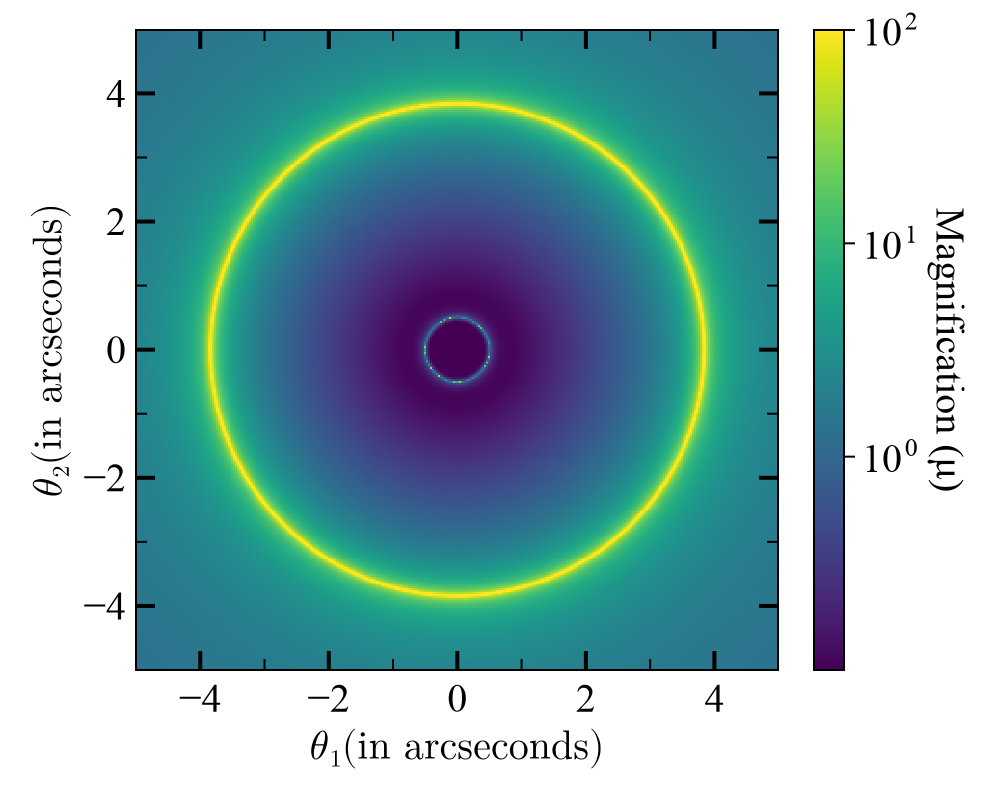

CairoMakie.Screen{IMAGE}


In [50]:
# Get NFW parameters
params = Lenses.parameter_NFWLens(cosmology=cosmo, z_d=zl, mass=1E13*MASS_SUN, x_s=0.5)

# Initialize NFW lens
lens = Lenses.init_NFWLens(D_d=Dol, x_s=0.5, rho_s=params.rho_s)

# Get scaled Jacobian components
dxx, dyy, dxy = Lenses.get_jacobian(lens, x, y)

# Re-scale Jacobian components to source plane
@. dxx = adis * dxx
@. dyy = adis * dyy
@. dxy = adis * dxy

# Get convergence and shear maps from Jacobian components
kappa = 0.5 .* (dxx .+ dyy)
gamma1 = 0.5 .* (dxx .- dyy)
gamma2 = dxy

# Get the magnification map
mu = abs.(1.0 ./ ((1 .- kappa).^2 .- (gamma1.^2 .+ gamma2.^2)))

# Plot the magnification map
fig, ax = Lenses.plot_sky(x, y)
cs = heatmap!(ax, x[:,1], y[1,:], mu, colormap=:viridis, colorrange=(1E-1, 1E2), colorscale=log10)
cb = Colorbar(fig[1,2], cs; label="Magnification (μ)", width=15, labelrotation=3π/2)
display(fig)